# Brain Tumor — DP-VAE quality evaluation

Trains a Brain Tumor VAE with Opacus DP-SGD over a sweep of target ε values and reports synthetic-image quality (α-precision, β-recall, reconstructions). Companion to `brain_vae_quality.ipynb` for the non-private upper bound.

> **Note:** The Brain Tumor MRI dataset was ultimately not used in the reported thesis experiments (see `README.md`). This notebook is retained as exploratory reference material.

In [20]:
import os
import json
import contextlib
import shutil
from typing import Literal, Union, Dict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import transforms, models, datasets
from sklearn.neighbors import NearestNeighbors

from opacus import PrivacyEngine
from opacus.validators import ModuleValidator

from dotenv import load_dotenv
import wandb

# Secrets and wandb init
load_dotenv()
wandb_api_key = os.getenv("WANDB_API_KEY")
if wandb_api_key:
    wandb.login(key=wandb_api_key)
else:
    print("WANDB_API_KEY not found; defaulting wandb to offline mode")
    os.environ["WANDB_MODE"] = "offline"



wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/timmr/.netrc


In [30]:
# Hyperparameters & sweep settings
DATA_PATH = '../../data/brain_tumor_dataset'
IMG_SIZE = 64
LATENT_DIM = 64
MAX_FILTERS = 128
EPOCHS = 500
BATCH_SIZE = 64
LR = 1e-3
KL_WARMUP_EPOCHS = 50
LOG_EVERY = 25  # epoch logging cadence

# Differential privacy
NOISE_MULTIPLIER = 1.0  # set 0.0 to mirror non-DP
MAX_GRAD_NORM = 1.2
DELTA = 1e-5

# Synthetic generation grid
SYN_TRAIN_EPOCHS = 300
SYN_BATCH_SIZE = 64
SYN_LATENT_DIM = 64
SYN_COUNT_PER_CLASS = 25

SEED_LIST = list(range(101, 105))  # keep small by default; expand as needed
NUM_SAMPLES_LIST = [2, 5, 10, 25]

WANDB_PROJECT = 'brain-vae-dp-quality'
WANDB_RUN_NAME = 'dp-vae-quality-batched'



In [31]:
# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using CUDA')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Using Apple Metal (MPS)')
else:
    device = torch.device('cpu')
    print('Using CPU')
print(f"Active device: {device}")



Using Apple Metal (MPS)
Active device: mps


In [32]:
# Data loading

def load_images(data_folder, image_size=64):
    X, y = [], []
    label_mapping = {"no": 0, "yes": 1}
    tfm = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])

    if not os.path.exists(data_folder):
        print(f"Data folder {data_folder} not found. Returning dummy data for dry-runs.")
        return np.random.rand(100, 3, image_size, image_size).astype(np.float32), np.zeros(100)

    for class_name, label in label_mapping.items():
        class_folder = os.path.join(data_folder, class_name)
        if not os.path.isdir(class_folder):
            print(f"Warning: {class_folder} missing; skipping.")
            continue
        for filename in os.listdir(class_folder):
            if filename.lower().endswith((".jpg", ".jpeg")):
                fp = os.path.join(class_folder, filename)
                try:
                    with Image.open(fp) as img:
                        image = img.convert("RGB")
                    X.append(tfm(image).numpy())
                    y.append(label)
                except Exception as e:
                    print(f"Error loading {fp}: {e}")
    return np.array(X), np.array(y)

X_raw, y_raw = load_images(DATA_PATH, image_size=IMG_SIZE)
X = torch.tensor(X_raw, dtype=torch.float32)
y = torch.tensor(y_raw, dtype=torch.long)
print(f"Data loaded: X {X.shape}, y {y.shape}")



Data loaded: X torch.Size([251, 3, 64, 64]), y torch.Size([251])


In [33]:
# VAE (matches baseline; BatchNorm will be fixed by ModuleValidator)
class Encoder(nn.Module):
    def __init__(self, num_latent_dims, num_img_channels, max_num_filters, device, img_size=64):
        super().__init__()
        nf1 = max_num_filters // 4
        nf2 = max_num_filters // 2
        nf3 = max_num_filters
        self.conv1 = nn.Conv2d(num_img_channels, nf1, 3, 2, 1)
        self.conv2 = nn.Conv2d(nf1, nf2, 3, 2, 1)
        self.conv3 = nn.Conv2d(nf2, nf3, 3, 2, 1)
        self.bn1 = nn.BatchNorm2d(nf1)
        self.bn2 = nn.BatchNorm2d(nf2)
        self.bn3 = nn.BatchNorm2d(nf3)
        flat = nf3 * (img_size // 8) * (img_size // 8)
        self.proj_mu = nn.Linear(flat, num_latent_dims)
        self.proj_log_var = nn.Linear(flat, num_latent_dims)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.conv1(x)))
        x = F.leaky_relu(self.bn2(self.conv2(x)))
        x = F.leaky_relu(self.bn3(self.conv3(x)))
        x = torch.flatten(x, 1)
        mu = self.proj_mu(x)
        logvar = self.proj_log_var(x)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        z = eps.mul(sigma).add_(mu)
        self.kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return z

class Decoder(nn.Module):
    def __init__(self, num_latent_dims, num_img_channels, max_num_filters, img_size=64):
        super().__init__()
        nf1 = max_num_filters
        nf2 = max_num_filters // 2
        nf3 = max_num_filters // 4
        self.input_shape = [nf1, img_size // 8, img_size // 8]
        flat = nf1 * (img_size // 8) * (img_size // 8)
        self.lin1 = nn.Linear(num_latent_dims, flat)
        self.conv1 = nn.ConvTranspose2d(nf1, nf2, 3, 2, 1, output_padding=1)
        self.conv2 = nn.ConvTranspose2d(nf2, nf3, 3, 2, 1, output_padding=1)
        self.conv3 = nn.ConvTranspose2d(nf3, num_img_channels, 3, 2, 1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(nf2)
        self.bn2 = nn.BatchNorm2d(nf3)

    def forward(self, z):
        x = self.lin1(z)
        x = x.view(-1, *self.input_shape)
        x = F.leaky_relu(self.bn1(self.conv1(x)))
        x = F.leaky_relu(self.bn2(self.conv2(x)))
        x = torch.sigmoid(self.conv3(x))
        return x

class VAE(nn.Module):
    def __init__(self, num_latent_dims, num_img_channels, max_num_filters, device, img_size=64):
        super().__init__()
        self.encoder = Encoder(num_latent_dims, num_img_channels, max_num_filters, device, img_size)
        self.decoder = Decoder(num_latent_dims, num_img_channels, max_num_filters, img_size)
        self.kl_div = 0

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        self.kl_div = self.encoder.kl_div
        return x_recon

    def decode(self, z):
        return self.decoder(z)



In [34]:
# Quality metrics (from non-DP notebook)
try:
    from torchvision.models import Inception_V3_Weights, ResNet18_Weights
except ImportError:
    Inception_V3_Weights = ResNet18_Weights = None

def _default_transform(img_size: int):
    return transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

def _load_backbone(name: Literal["inception", "resnet18"], device):
    if name == "inception":
        net = models.inception_v3(weights=Inception_V3_Weights.DEFAULT if Inception_V3_Weights else None, aux_logits=False)
        net.fc = torch.nn.Identity()
    elif name == "resnet18":
        net = models.resnet18(weights=ResNet18_Weights.DEFAULT if ResNet18_Weights else None)
        net.fc = torch.nn.Identity()
    else:
        raise ValueError(name)
    net.eval().to(device)
    return net

@torch.no_grad()
def _embed(data: Union[str, Dataset], model: torch.nn.Module, batch: int, device, img_size: int) -> np.ndarray:
    dataset = datasets.ImageFolder(data, _default_transform(img_size)) if isinstance(data, str) else data
    loader = DataLoader(dataset, batch_size=batch, shuffle=False, num_workers=0, pin_memory=True)
    feats = []
    for x, _ in loader:
        feats.append(model(x.to(device, non_blocking=True)).cpu())
    return torch.cat(feats).numpy()

def evaluate_fidelity_diversity(real_source, fake_source, alpha=0.90, beta=0.90, batch_size=64,
                                device=None, backbone: Literal["inception", "resnet18"] = "inception",
                                input_size: int | None = None) -> Dict[str, float]:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    if input_size is None:
        input_size = 299 if backbone == "inception" else 224
    net = _load_backbone(backbone, device)
    real_f = _embed(real_source, net, batch_size, device, input_size)
    fake_f = _embed(fake_source, net, batch_size, device, input_size)
    c_r = real_f.mean(0, keepdims=True)
    r_thr = np.quantile(np.linalg.norm(real_f - c_r, axis=1), alpha)
    alpha_prec = float((np.linalg.norm(fake_f - c_r, axis=1) <= r_thr).mean())
    c_g = fake_f.mean(0, keepdims=True)
    g_thr = np.quantile(np.linalg.norm(fake_f - c_g, axis=1), beta)
    beta_rec = float((np.linalg.norm(real_f - c_g, axis=1) <= g_thr).mean())
    nn_r2 = NearestNeighbors(n_neighbors=2).fit(real_f)
    d_r2 = nn_r2.kneighbors(real_f, return_distance=True)[0][:, 1]
    nn_fg = NearestNeighbors(n_neighbors=1).fit(real_f)
    d_fg, idx_fg = nn_fg.kneighbors(fake_f, return_distance=True)
    unauth_mask = (d_fg.flatten() <= d_r2[idx_fg.flatten()])
    authenticity = float(1.0 - unauth_mask.mean())
    return dict(alpha_precision=alpha_prec, beta_recall=beta_rec, authenticity=authenticity)

class TensorImageDataset(Dataset):
    def __init__(self, tensor: torch.Tensor, target_size: int = None):
        self.tensor = tensor
        if target_size is None:
            self.prep = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            self.resize = False
        else:
            self.to_pil = transforms.ToPILImage()
            self.prep = transforms.Compose([
                transforms.Resize(target_size, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.CenterCrop(target_size),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
            self.resize = True

    def __len__(self):
        return self.tensor.size(0)

    def __getitem__(self, idx):
        if self.resize:
            img = self.to_pil(self.tensor[idx])
            img = self.prep(img)
        else:
            img = self.prep(self.tensor[idx])
        return img, 0



In [35]:
# DP training helpers with batched wandb logging

def train_dp_vae(data_tensor: torch.Tensor, epochs: int, batch_size: int, latent_dim: int,
                 max_filters: int, lr: float, noise_multiplier: float, max_grad_norm: float,
                 kl_warmup: int, device, delta: float = 1e-5, run: wandb.sdk.wandb_run.Run | None = None,
                 label_name: str | None = None, log_every: int = 25):
    dl = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=True)

    model = VAE(latent_dim, 3, max_filters, device, IMG_SIZE)
    errors = ModuleValidator.validate(model, strict=False)
    if len(errors) > 0:
        model = ModuleValidator.fix(model)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    privacy_engine = PrivacyEngine()
    model, optimizer, dl = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=dl,
        noise_multiplier=noise_multiplier,
        max_grad_norm=max_grad_norm,
    )

    eps_history = []
    model.train()
    last_loss = None

    for epoch in range(epochs):
        total_loss = 0.0
        for (x,) in dl:
            x = x.to(device)
            optimizer.zero_grad()
            x_hat = model(x)
            recon_loss = F.mse_loss(x_hat, x, reduction='sum')
            kl_div = model.kl_div if hasattr(model, 'kl_div') else model._module.kl_div
            kl_weight = min(1.0, epoch / max(1, kl_warmup))
            loss = recon_loss + kl_weight * kl_div
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        epsilon = privacy_engine.get_epsilon(delta) if noise_multiplier > 0 else float('inf')
        eps_history.append(epsilon)
        last_loss = total_loss / len(dl.dataset)

        # Heartbeat logging (batched): use commit=False for multiple keys per step
        if run and ((epoch + 1) % log_every == 0 or epoch == 0 or epoch + 1 == epochs):
            run.log({
                'train/loss': last_loss,
                'train/epsilon': epsilon,
                'train/epoch': epoch + 1,
                'train/label': label_name or 'all'
            }, commit=True)

    return model, eps_history, last_loss


def sample_from_model(model: nn.Module, num: int, latent_dim: int, device):
    decoder_func = model.decode if hasattr(model, 'decode') else model._module.decode
    with torch.no_grad():
        z = torch.randn(num, latent_dim, device=device)
        return decoder_func(z).cpu().clamp(0.0, 1.0)


def log_images_to_wandb(run, images: torch.Tensor, caption: str, max_images: int = 8):
    if run is None or images is None:
        return
    imgs = images[:max_images]
    wandb_imgs = [wandb.Image(img.permute(1, 2, 0).numpy(), caption=f"{caption}-{i}") for i, img in enumerate(imgs)]
    run.log({f"images/{caption}": wandb_imgs}, commit=True)



In [36]:
# DP training + generation + evaluation per label (batched logging)

def train_and_generate_by_label_dp(
    data_tensor: torch.Tensor,
    label_tensor: torch.Tensor,
    synthetic_ep: int = SYN_TRAIN_EPOCHS,
    synthetic_batch_size: int = SYN_BATCH_SIZE,
    synthetic_latent_dim: int = SYN_LATENT_DIM,
    synthetic_count: int = SYN_COUNT_PER_CLASS,
    target_size: int | None = 64,
    run: wandb.sdk.wandb_run.Run | None = None,
    seed: int | None = None,
):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    synthetic_images_list, synthetic_labels_list = [], []
    epsilon_per_label = {}

    for lbl in torch.unique(label_tensor):
        mask = (label_tensor == lbl)
        subset_data = data_tensor[mask]
        synth_num = synthetic_count

        model, eps_history, last_loss = train_dp_vae(
            subset_data,
            epochs=synthetic_ep,
            batch_size=synthetic_batch_size,
            latent_dim=synthetic_latent_dim,
            max_filters=MAX_FILTERS,
            lr=LR,
            noise_multiplier=NOISE_MULTIPLIER,
            max_grad_norm=MAX_GRAD_NORM,
            kl_warmup=KL_WARMUP_EPOCHS,
            device=device,
            delta=DELTA,
            run=run,
            label_name=f"label-{lbl.item()}",
            log_every=LOG_EVERY,
        )

        eps_last = eps_history[-1] if eps_history else float('nan')
        epsilon_per_label[int(lbl.item())] = eps_last

        synth_imgs = sample_from_model(model, synth_num, synthetic_latent_dim, device)
        synthetic_images_list.append(synth_imgs)
        synthetic_labels_list.append(torch.full((synth_imgs.size(0),), lbl.item(), dtype=torch.long))

        if run:
            run.log({
                'label/epsilon_last': eps_last,
                'label/loss_last': last_loss,
                'label/id': int(lbl.item()),
            }, commit=False)
            log_images_to_wandb(run, synth_imgs, caption=f"label-{lbl.item()}")

    synthetic_x = torch.cat(synthetic_images_list, dim=0).clamp(0.0, 1.0)
    synthetic_y = torch.cat(synthetic_labels_list, dim=0)

    real_ds = TensorImageDataset(data_tensor, target_size=target_size)
    fake_ds = TensorImageDataset(synthetic_x, target_size=target_size)
    metrics = evaluate_fidelity_diversity(real_ds, fake_ds, alpha=0.90, beta=0.90,
                                          batch_size=256, backbone="resnet18", input_size=64, device=device)

    if run:
        run.log({
            "metrics/alpha_precision": metrics["alpha_precision"],
            "metrics/beta_recall": metrics["beta_recall"],
            "metrics/authenticity": metrics["authenticity"],
            "privacy/epsilon_mean": float(np.nanmean(list(epsilon_per_label.values()))),
        }, commit=True)

    return synthetic_x, synthetic_y, metrics, epsilon_per_label



In [37]:
# Experiment sweep with batched logging

def get_dp_syn_data(X, y, num_samples, seed, scores, run=None):
    np.random.seed(seed)
    torch.manual_seed(seed)

    idx = np.random.permutation(X.shape[0])
    pos_idx = idx[y[idx] == 1][:num_samples]
    neg_idx = idx[y[idx] == 0][:num_samples]
    balanced_idx = np.concatenate([pos_idx, neg_idx], axis=0)

    X_sub = X[balanced_idx]
    y_sub = y[balanced_idx]

    with contextlib.redirect_stdout(open(os.devnull, 'w')):
        syn_x, syn_y, metrics, eps = train_and_generate_by_label_dp(
            X_sub,
            y_sub,
            synthetic_count=num_samples,
            target_size=64,
            run=run,
            seed=seed,
        )

    scores['Number of samples'].append(num_samples)
    scores['Seed'].append(seed)
    scores['Metrics'].append(metrics)
    scores['Epsilon'].append(eps)

    if run:
        run.log({
            'exp/num_samples_per_class': num_samples,
            'exp/seed': seed,
            'exp/alpha_precision': metrics['alpha_precision'],
            'exp/beta_recall': metrics['beta_recall'],
            'exp/authenticity': metrics['authenticity'],
            'exp/eps_mean': float(np.nanmean(list(eps.values())))
        }, commit=True)

    return scores


scores = {'Number of samples': [], 'Seed': [], 'Metrics': [], 'Epsilon': []}

total_runs = len(SEED_LIST) * len(NUM_SAMPLES_LIST)
current_run = 0

run = wandb.run or wandb.init(project=WANDB_PROJECT, name=WANDB_RUN_NAME,
                              config=dict(
                                  noise_multiplier=NOISE_MULTIPLIER,
                                  max_grad_norm=MAX_GRAD_NORM,
                                  epochs=SYN_TRAIN_EPOCHS,
                                  batch_size=SYN_BATCH_SIZE,
                                  latent_dim=SYN_LATENT_DIM,
                                  seeds=len(SEED_LIST),
                                  samples_grid=NUM_SAMPLES_LIST,
                                  log_every=LOG_EVERY,
                              ))

try:
    if 'X' in locals():
        print(f"Starting DP experiment: {total_runs} runs scheduled.")
        for seed_ in SEED_LIST:
            for num_samples_ in NUM_SAMPLES_LIST:
                current_run += 1
                print(f"Run {current_run}/{total_runs} | Seed: {seed_} | Samples/Class: {num_samples_} ... ", end='\r')
                scores = get_dp_syn_data(X, y, num_samples_, seed_, scores, run=run)
        print("\nExperiment complete.")
    else:
        print("X not loaded; skipping experiment.")
finally:
    if run:
        wandb.finish()

# Aggregate metrics by sample count for plotting

grouped_scores = {}
for i in range(len(scores['Number of samples'])):
    num_samples = scores['Number of samples'][i]
    if num_samples not in grouped_scores:
        grouped_scores[num_samples] = {'Metrics': {}}
    for metric, value in scores['Metrics'][i].items():
        grouped_scores[num_samples]['Metrics'].setdefault(metric, []).append(value)

os.makedirs('../experiments/brain_tumor_dp_syn/scores', exist_ok=True)
with open('../experiments/brain_tumor_dp_syn/scores/dp_syn_scores.json', 'w') as f:
    json.dump(grouped_scores, f, indent=4)



Starting DP experiment: 16 runs scheduled.


<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/4041720053.py:39: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:67: RuntimeWarning: divide by zero encountered in log
  z = np.log(np.where(t > np.log(1 - q), (np.exp(t) + q - 1) / q, 1))
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:70: RuntimeWarning: di

<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/4041720053.py:39: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:67: RuntimeWarning: divide by zero encountered in log
  z = np.log(np.where(t > np.log(1 - q), (np.exp(t) + q - 1) / q, 1))
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:70: RuntimeWarning: di

<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/4041720053.py:39: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:67: RuntimeWarning: divide by zero encountered in log
  z = np.log(np.where(t > np.log(1 - q), (np.exp(t) + q - 1) / q, 1))
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:70: RuntimeWarning: di

<repo>/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/4041720053.py:39: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:67: Runt

...

<repo>/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/4041720053.py:39: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:67: Runt

<repo>/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/4041720053.py:39: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:67: RuntimeWarning: divide by zero encountered in log
  z = np.log(np.where(t > np.log(1 - q), (np.exp(t) + q - 1) / q, 1))
<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/prv/prvs.py:70: RuntimeWarning: di


Experiment complete.


exp/alpha_precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
exp/authenticity,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
exp/beta_recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
exp/eps_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
exp/num_samples_per_class,▁▂▃█▁▂▃█▁▂▃█▁▂▃█
exp/seed,▁▁▁▁▃▃▃▃▆▆▆▆████
label/epsilon_last,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
label/id,▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█
label/loss_last,▆▆▃▄▃▃▁▂█▄▃▄▂▂▂▂▆▆▅▃▃▃▁▂█▅▄▃▃▂▁▂
metrics/alpha_precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+6,...


/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/233708693.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=plot_labels, widths=0.4, showfliers=True)
/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/233708693.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=plot_labels, widths=0.4, showfliers=True)
/var/folders/th/dk0wskms21z5yttn5llbsg680000gn/T/ipykernel_67303/233708693.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=plot_labels, 

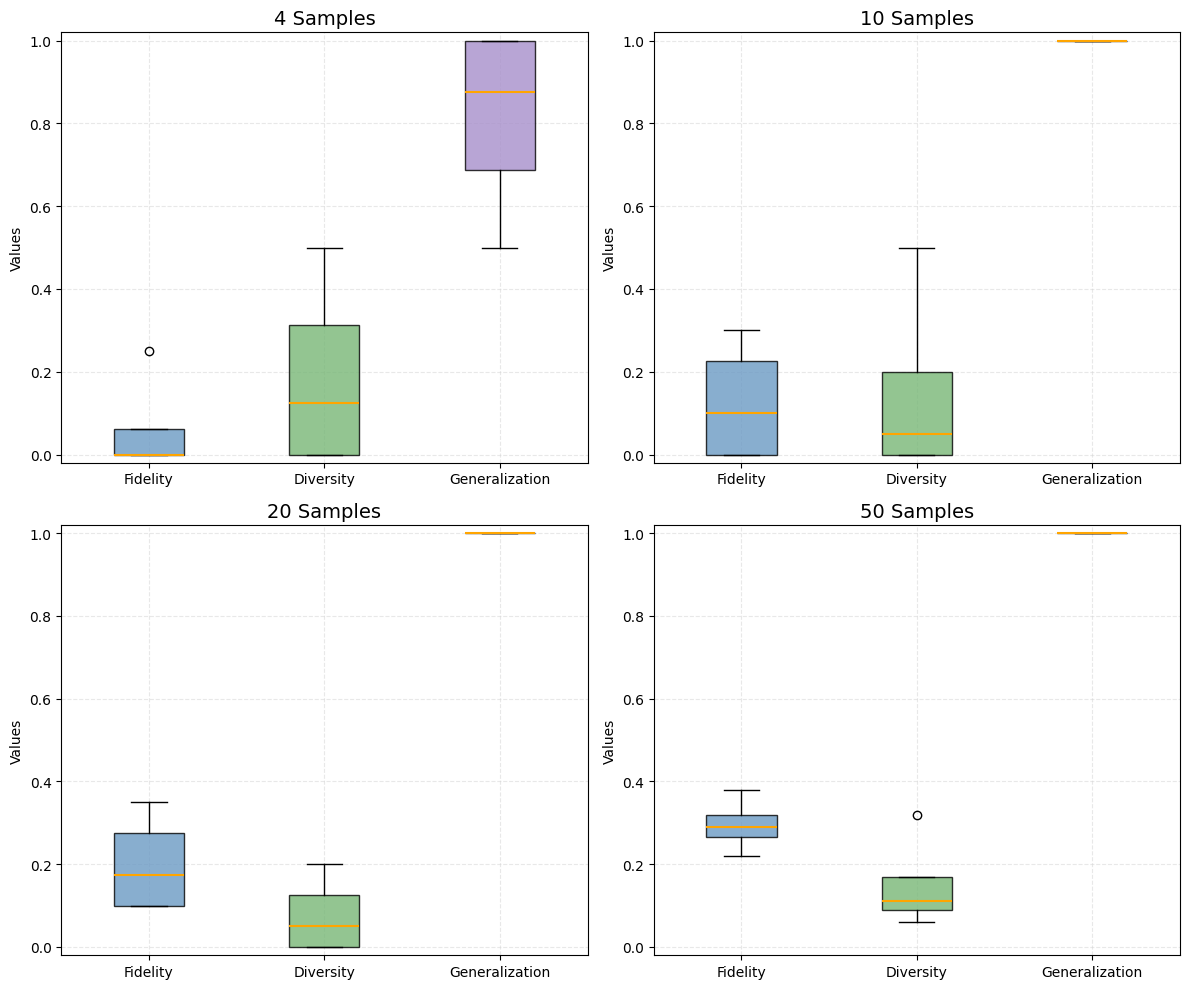

In [29]:
# Visualization: boxplots similar to non-DP quality notebook

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sample_keys = [2, 5, 10, 25]
plot_titles = [4, 10, 20, 50]
metrics_order = ['alpha_precision', 'beta_recall', 'authenticity']
plot_labels = ['Fidelity', 'Diversity', 'Generalization']
colors = ['#6b9ac4', '#78b776', '#a78fcb']

for i, s_key in enumerate(sample_keys):
    ax = axes[i]
    if s_key in grouped_scores:
        metrics_dict = grouped_scores[s_key]['Metrics']
        data = [metrics_dict[m] for m in metrics_order]
        bp = ax.boxplot(data, patch_artist=True, labels=plot_labels, widths=0.4, showfliers=True)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        plt.setp(bp['medians'], color='orange', linewidth=1.5)

    ax.set_title(f"{plot_titles[i]} Samples", fontsize=14)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("Values")
    ax.grid(True, linestyle='--', alpha=0.5, color='lightgrey')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

